## Noob2Pro CF

This project is an analytical tool which fetches data directly from the codeforces api, analyses the data and provides some useful insights. Then, it recommends topicwise questions using scipy.stats.linregress. 

### Pre-requisites:
install dependencies
```bash 
pip install numpy pandas scipy matplotlib requests ipython
```
### User guidelines
Run all cells and enter the users codeforces handles separated by commas.
For each handle the notebook will fetch and save raw data to `files/`

In [25]:
import os
import sys
import time
import requests
import itertools
from datetime import datetime

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

We create a persistent HTTP session, it reuses the connection rather than reconnecting every time and hence, saves time.
It fetches the user's data and problems with a rating in the range(target-200, target+200) where target is calculated using 
scipy.stats.linregress. Then, it sorts the problems based on proximity of ratings to the mid value and the selects the top 5 problems for recommendation. We have used class structure so that the final project is extendable.

In [26]:
#API
class CFClient:
    def __init__(self):
        self.session= requests.Session()

    def cf_get(self, endpoint, params=None):
        url= f"https://codeforces.com/api/{endpoint}"
        for attempt in range(3):
            try:
                r= self.session.get(url, params=params, timeout=15)
                data= r.json()
                if data.get("status")== "OK":
                    return data["result"]
                print("Unknown error in API ")
                return None
            
            except Exception as exc:
                #if not last attempt, retry after 1.5 sec.
                if attempt< 3- 1:
                    time.sleep(1.5)
                else:
                    print(f"API request failed")
        return None

    def fetch_user_info(self, handle):
        result= self.cf_get("user.info", {"handles": handle})
        return result[0] if result else None

    def fetch_submissions(self, handle, count=500):
        return self.cf_get("user.status", {"handle": handle, "count": count}) or []

    def fetch_rating_history(self, handle):
        return self.cf_get("user.rating", {"handle": handle}) or []

    def fetch_problems_by_tag(self, cf_tag, min_rating, max_rating, count=5):
        result= self.cf_get("problemset.problems", {"tags": cf_tag})
        if not result: return []

        problems= result.get("problems", []) if isinstance(result, dict) else []
        filtered= [p for p in problems if p.get("rating") and min_rating<= p["rating"] <= max_rating]
        
        mid= (min_rating + max_rating)// 2
        filtered.sort(key=lambda p : abs(p["rating"] - mid))

        out= []
        for p in filtered[:count]:
            out.append({
                "title": p.get("name", "Unknown"),
                "link": f"https://codeforces.com/problemset/problem/{p.get('contestId','')}/{p.get('index', '')}",
                "rating": p["rating"],
            })
        return out

_default_client= CFClient()
def fetch_problems_by_tag(cf_tag, min_rating, max_rating, count=5):
    return _default_client.fetch_problems_by_tag(cf_tag, min_rating, max_rating, count)

def save_raw_data_to_csv(handle, user_info, submissions, rating_history):
    os.makedirs("files", exist_ok=True) 
    if user_info: pd.DataFrame([user_info]).to_csv(f"files/cf_user_info_{handle}.csv", index=False)
    if submissions: pd.json_normalize(submissions).to_csv(f"files/cf_submissions_{handle}.csv", index=False)
    if rating_history: pd.DataFrame(rating_history).to_csv(f"files/cf_rating_history_{handle}.csv", index=False)

In [27]:
#tag map groups similar topics 
CF_TAG_MAP= {
    "dp": "Dynamic Programming", 
    "graphs": "Graphs", 
    "dfs and similar": "Graphs",
    "shortest paths": "Graphs", 
    "trees": "Trees", 
    "math": "Math", 
    "combinatorics": "Math",
    "number theory": "Number Theory", 
    "greedy": "Greedy", 
    "constructive algorithms": "Constructive algo",
    "binary search": "Binary Search", 
    "ternary search": "Binary Search", 
    "data structures": "Data Structures",
    "strings": "Strings", 
    "string suffix structures": "Strings", 
    "geometry": "Geometry",
    "sortings": "Sorting", 
    "brute force": "Brute Force", 
    "implementation": "Brute Force",
    "two pointers": "Two Pointers", 
    "bitmasks": "Bit Manipulation", 
    "games": "Math",
}

def classify_tags(tags):
    matched= {CF_TAG_MAP.get(tag) for tag in tags if CF_TAG_MAP.get(tag)}
    return list(matched) if matched else ["Other"]

The **process_submissions** function extracts the features out of raw data and returns a pandas dataframe. 

Then, the **compute_topic_stats** function is being used for feature engineering and it creates new features out of existing features.

In [ ]:
#Data Processor

def process_submissions(raw_subs):

    rows= [] #stores data of each submission(problem_id, topic, time etc)
 
    for sub in raw_subs:
        prob= sub.get("problem", {})
        ts= sub.get("creationTimeSeconds", 0)
        for topic in classify_tags(prob.get("tags", [])):
            rows.append({
                "problem_id": f"{prob.get('contestId', 0)}{prob.get('index', '?')}",
                "topic": topic, 
                "verdict":sub.get("verdict", ""), 
                "rating": prob.get("rating"),
                "timestamp": ts, 
                "datetime": datetime.fromtimestamp(ts),
            })
    df= pd.DataFrame(rows)
    if not df.empty: df["datetime"]= pd.to_datetime(df["datetime"]) #create a pandas datetime object
    return df

def compute_topic_stats(df):
    if df.empty: 
        return pd.DataFrame()
    
    base= df.groupby("topic").agg(
        total_attempts=("verdict", "count"),
        accepted=("verdict", lambda x: (x== "OK").sum()),
        wrong_answer=("verdict", lambda x: (x== "WRONG_ANSWER").sum()),
        tle=("verdict", lambda x: (x== "TIME_LIMIT_EXCEEDED").sum()),
        ce=("verdict", lambda x: (x== "COMPILATION_ERROR").sum()),
        unique_problems=("problem_id", "nunique"),
        last_activity_ts=("timestamp", "max"),
    ).reset_index()

    base["ac_rate"]= (base["accepted"] / base["total_attempts"] * 100).round(1)
    base["last_activity_dt"]= pd.to_datetime(base["last_activity_ts"], unit="s")

    ac_df= df[df["verdict"] == "OK"]
    ac_stats= ac_df.groupby("topic")["rating"].agg(avg_rating="mean", max_rating="max", med_rating="median").reset_index()
    all_stats= df.groupby("topic")["rating"].mean().rename("avg_rating_attempted").reset_index()


    result= base.merge(ac_stats, on="topic", how="left")
    result= result.merge(all_stats, on="topic", how="left")

    result[["avg_rating", "max_rating", "med_rating"]] = result[["avg_rating", "max_rating", "med_rating"]].fillna(0).round(1)
    result["avg_rating_attempted"] = result["avg_rating_attempted"].fillna(0).round(1)
    return result


The function below classifies the topic as strong if the acceptance rate is >= 70% and weak if <50%

In [29]:
def classify_topics(stats_df):
    #minimum no of questions attempted is 3 for a topic to be classified as weak or strong 
    eligible= stats_df[stats_df["total_attempts"] >= 3]

    strong_mask= (eligible["ac_rate"] >= 70) & (eligible["unique_problems"] >= 3)
    weak_mask= (eligible["ac_rate"] < 50) | (eligible["unique_problems"] < 3)
    return (
        sorted(eligible.loc[weak_mask & ~strong_mask, "topic"].tolist()),
        sorted(eligible.loc[~strong_mask & ~weak_mask, "topic"].tolist()),
        sorted(eligible.loc[strong_mask, "topic"].tolist())
    )

The **detect_forgotten_topics** function gives a warning if a particular topic was not touched since the last 14 days and classifies it as forgotten if it was not touched since last 30 days.

In [30]:
def detect_forgotten_topics(stats_df):
    df= stats_df.copy()
    df["days_since"]= (datetime.now() - df["last_activity_dt"]).dt.days
    forgotten= df[df["days_since"] >= 14].copy()
    forgotten["severity"]= np.where(forgotten["days_since"] >= 30, "forgotten", "warning")
    return forgotten.sort_values("days_since", ascending=False).reset_index(drop=True)

Use scipy for linear regression of rating with number of contests given.

In [31]:
def rating_trend(rating_history):
    if not rating_history or len(rating_history)< 3: return {"label": "N/A"}
    rh_df= pd.DataFrame(rating_history)[["ratingUpdateTimeSeconds", "newRating"]].sort_values("ratingUpdateTimeSeconds").reset_index(drop=True)
    
    y= rh_df["newRating"].values.astype(float)
    x= np.arange(len(rh_df), dtype=float)
    

    res= stats.linregress(x, y)
    slope, intercept, r_squared= res.slope, res.intercept, round(res.rvalue**2, 3)
    
    y_pred= intercept + slope * x
    delta= int(y[-1] - y[0])
    direction= "up" if slope > 0 else "down"
    label= f"{direction} {abs(slope):.1f} pts/contest  (R2={r_squared:.2f})"

    return {
        "slope":     round(slope, 2),
        "r_squared": r_squared,
        "label":     label,
        "delta":     delta,
        "std":       round(float(np.std(y)), 1),
        "y":         y.tolist(),
        "y_pred":    y_pred.tolist(),
        "rh_df":     rh_df
    }

In [32]:
TOPIC_TO_CF_TAG = {
    "Dynamic Programming": "dp", "Graphs": "graphs", "Trees": "trees", "Math": "math",
    "Greedy": "greedy", "Binary Search": "binary search", "Data Structures": "data structures",
    "Strings": "strings", "Geometry": "geometry", "Sorting": "sortings", "Brute Force": "brute force",
    "Number Theory": "number theory", "Two Pointers": "two pointers", "Bit Manipulation": "bitmasks"
}

#Calculates regression for a specific topic using scipy.stats.linregress.
def get_topic_regression(topic_df):

    df= topic_df.dropna(subset=["rating"]).sort_values("timestamp").reset_index(drop=True)
    n_solved = len(df)
    
    # We need at least 2 points for a line
    if n_solved< 2:
        return None, n_solved, None
    
    y= df["rating"].values.astype(float)
    x= np.arange(n_solved, dtype=float)
    
    # Scipy linear regression
    # returns: slope, intercept, r_value, p_value, std_err
    res= stats.linregress(x, y)
    
    beta= [res.intercept, res.slope]
    r2= round(res.rvalue**2, 3)
    
    return beta, n_solved, r2

This function uses get_topic_regression function to get the values of slope and intercept of the regression line and then the rating of the recommended question is such that it is slightly greater than the predicted value(adds a boost).

In [33]:
def recommend(topics, stats_df, submissions_df, boost=200):
    recs= {}
    for topic in topics:
        rows= stats_df[stats_df["topic"] == topic]
        if rows.empty: 
            continue
        row= rows.iloc[0]
        
        # Filter for solved problems in this topic
        topic_df= submissions_df[(submissions_df["topic"] == topic) & (submissions_df["verdict"] == "OK")]
        
        beta, n_solved, r2= get_topic_regression(topic_df)
        
        predicted= None
        if beta is not None:
            # Predict the rating for the next problem
            #applying y= m*x+b and then clipping it to a value between 800 and 3500
            predicted= int(np.clip(beta[0] + beta[1] * n_solved, 800, 3500))
        
        current_avg= max(float(row.get("avg_rating", 0) or 0), 800.0)
        
        if predicted:
            # Logic: recommend something slightly harder than your predicted skill
            target, method= min(max(predicted, current_avg) + boost, current_avg + 400), "Topic Scipy Reg + boost"
        else:
            target, method=800, "start from 800"

        # Calculate priority ( increase priority of low AC rate, low avg rating and low unique problems)
        priority= float(np.linalg.norm(np.array([
            max(0.0, 60 - float(row.get("ac_rate", 0) or 0)),
            max(0.0, 1500 - float(row.get("avg_rating", 0) or 0)) / 100,
            max(0.0, 10 - float(row.get("unique_problems", 0) or 0))
        ])))

        recs[topic] = {
            "current_avg_rating": round(current_avg),
            "target_rating": round(target),
            "target_method": method,
            "priority_score": round(priority, 2),
            "top_problems": fetch_problems_by_tag(TOPIC_TO_CF_TAG.get(topic, ""), max(800, target - 200), min(3500, target + 200)),
            "predicted_next_rating": predicted,
            "ols_r2": r2
        }
        
    return dict(sorted(recs.items(), key=lambda x: x[1]["priority_score"], reverse=True))

## *CHARTS*

In [ ]:
#gives the bar chart of acceptance rate of each topic and classifies them as strong, weak and average
def draw_ac_rate(ax, stats_df):
    #if the dataframe is empty, then return 
    if stats_df.empty: 
        ax.set_visible(False)
        return

    df= stats_df.sort_values("ac_rate").reset_index(drop=True)

    #green coloured bars represent the strong topics, yellow bars represent average and red bars represent weak topics. 
    colors= ["green" if r >= 70 else "orange" if r >= 50 else "red" for r in df["ac_rate"]]
    ax.barh(df["topic"], df["ac_rate"], color=colors)

    ax.axvline(50, linestyle="--", alpha=0.7, label="Average (50%)")
    ax.axvline(70,  linestyle="--", alpha=0.7, label="Strong (70%)")
    ax.set_title("AC Rate by Topic")
    ax.legend(fontsize=8)

#give the average and maximum rating of question solved of each topic
def draw_rating_dist(ax, stats_df):
    if stats_df.empty:
        ax.set_visible(False)
        return

    rated= stats_df[stats_df["avg_rating"] > 0].sort_values("avg_rating").reset_index(drop=True)
    if rated.empty: 
        ax.set_visible(False)
        return
    
    #w is the width of the bar
    x, w= np.arange(len(rated)), 0.35
    ax.bar(x - w/2, rated["avg_rating"], width=w, label="Avg Rating", color="purple")
    ax.bar(x + w/2, rated["max_rating"], width=w, label="Max Rating", color="blue")
    ax.set_xticks(x); ax.set_xticklabels(rated["topic"], rotation=45, ha="right", fontsize=8)
    ax.set_title("Problem Ratings by Topic")
    ax.legend(fontsize=8)

#gives the piechart showing the percentages of types of verdicts(accepted, wrong answer, time limit exceeded,etc)
def draw_verdict_pie(ax, stats_df):
    if stats_df.empty:
        ax.set_visible(False)
        return

    ac, wa, tle, ce= stats_df["accepted"].sum(), stats_df["wrong_answer"].sum(),stats_df["tle"].sum(), stats_df["ce"].sum()
    other= max(0, stats_df["total_attempts"].sum() - ac - wa - tle - ce)
    sizes= [s for s in [ac, wa, tle, ce, other] if s > 0]
    labels= [l for s, l in zip([ac, wa, tle, ce, other], ["Accepted", "WA", "TLE", "CE", "Other"]) if s > 0]
    if not sizes:
        ax.set_visible(False)
        return
    ax.pie(sizes, labels=labels, autopct="%1.1f%%")
    ax.set_title("Verdict Breakdown")

#shows the monthly activity of the user
def draw_activity_trend(ax, df):
    if df.empty: 
        ax.set_visible(False)
        return
    
    #stores the number of submissions per month
    monthly= df.assign(month=df["datetime"].dt.to_period("M")).groupby("month").size().reset_index(name="count")
    if monthly.empty:
        ax.set_visible(False)
        return
    x, y= np.arange(len(monthly)), monthly["count"].values.astype(float)
    ax.bar(x, y, color="orange", alpha=0.5)

    #display a maximum of ten bars
    step= max(1, len(monthly) // 10)

    ax.set_xticks(x[::step]); ax.set_xticklabels(monthly["month"].astype(str).values[::step], rotation=35, ha="right")
    ax.set_title("Submission Activity")

""" shows the scatterplot bw the dates of attempted contests vs rating and then makes an 
ols(ordinary least squares) regression line """
def draw_rating_history(ax, trend):
    if not trend or trend.get("label")== "N/A": 
        ax.set_visible(False)
        return
    rh_df, y, y_pred= trend.get("rh_df"), np.array(trend["y"]), np.array(trend["y_pred"])
    if rh_df is None or rh_df.empty:
        ax.set_visible(False)
        return
    dates= pd.to_datetime(rh_df["ratingUpdateTimeSeconds"], unit="s")
    ax.plot(dates, y, "o",  alpha=0.6, label="Rating")
    ax.plot(dates, y_pred, "-",  label=f"OLS trend (R²={trend['r_squared']})")

    ax.set_title("Rating History (OLS)")
    
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=35)
    plt.setp(ax.get_xticklabels(), ha="right")

#shows the forgotten topics in red (topics not touched since 30/more than 30 days) 
#gives a warning for topics not touched since 14/more than 14 days
def draw_forgotten_topics(ax, forgotten_df):
    if forgotten_df is None or forgotten_df.empty: 
        ax.set_visible(False)
        return

    colors = ["red" if s == "forgotten" else "orange" for s in forgotten_df["severity"]]
    ax.barh(forgotten_df["topic"], forgotten_df["days_since"], color=colors)
    ax.axvline(30, color="red", linestyle="--", label="Forgotten")
    ax.axvline(14, color="orange", linestyle="--", label="Warning")
    ax.set_title("Days Since Last Attempt")
    ax.legend(fontsize=8)

#apply min max normalisation so that the user can focus on the weakest topic.
def draw_performance_heatmap(ax_left, ax_right,stats_df):
    ax_right.set_visible(False) 
    if stats_df.empty: 
        ax_left.set_visible(False)
        return
    cols= ["ac_rate", "avg_rating", "unique_problems", "total_attempts"]
    heatmap_df= stats_df.set_index("topic")[cols].copy()

    #apply min-max normalisation on each column to convert it to range [0, 1]
    for col in cols:
        col_min, col_max= heatmap_df[col].min(), heatmap_df[col].max()
        heatmap_df[col]= (heatmap_df[col]- col_min)/ (col_max - col_min + 1e-9)

    im= ax_left.imshow(heatmap_df.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

    ax_left.set_xticks(range(len(cols)))
    ax_left.set_xticklabels(cols, fontsize=10)
    ax_left.set_yticks(range(len(heatmap_df)))
    ax_left.set_yticklabels(heatmap_df.index, fontsize=10)
    ax_left.set_title("Performance Heatmap (Normalised)")

    # Annotate each cell with its value
    for i in range(len(heatmap_df)):
        for j in range(len(cols)):
            ax_left.text(j, i, f"{heatmap_df.values[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black")

    plt.colorbar(im, ax=ax_left, shrink=0.8)


def render_dashboard(stats_df, trend, df, forgotten_df):
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))  
    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    
    draw_ac_rate(axes[0, 0], stats_df)
    draw_rating_dist(axes[0, 1], stats_df)
    draw_verdict_pie(axes[1, 0], stats_df)
    draw_activity_trend(axes[1, 1], df)
    draw_rating_history(axes[2, 0], trend)
    draw_forgotten_topics(axes[2, 1], forgotten_df)
    draw_performance_heatmap(axes[3,0],axes[3,1],stats_df)  # spans both columns
    
    plt.show()

### Main Engine 
The class UserSession makes it possible to analyse multiple user's data at the same time. 

The class CPAnalyserEngine calls all the functions i.e. fetch, process data and generate recommendations.

Processing @saniabansal07...


## CP Analysis for **@saniabansal07**

**Rank:** Newbie | **Rating:** 792

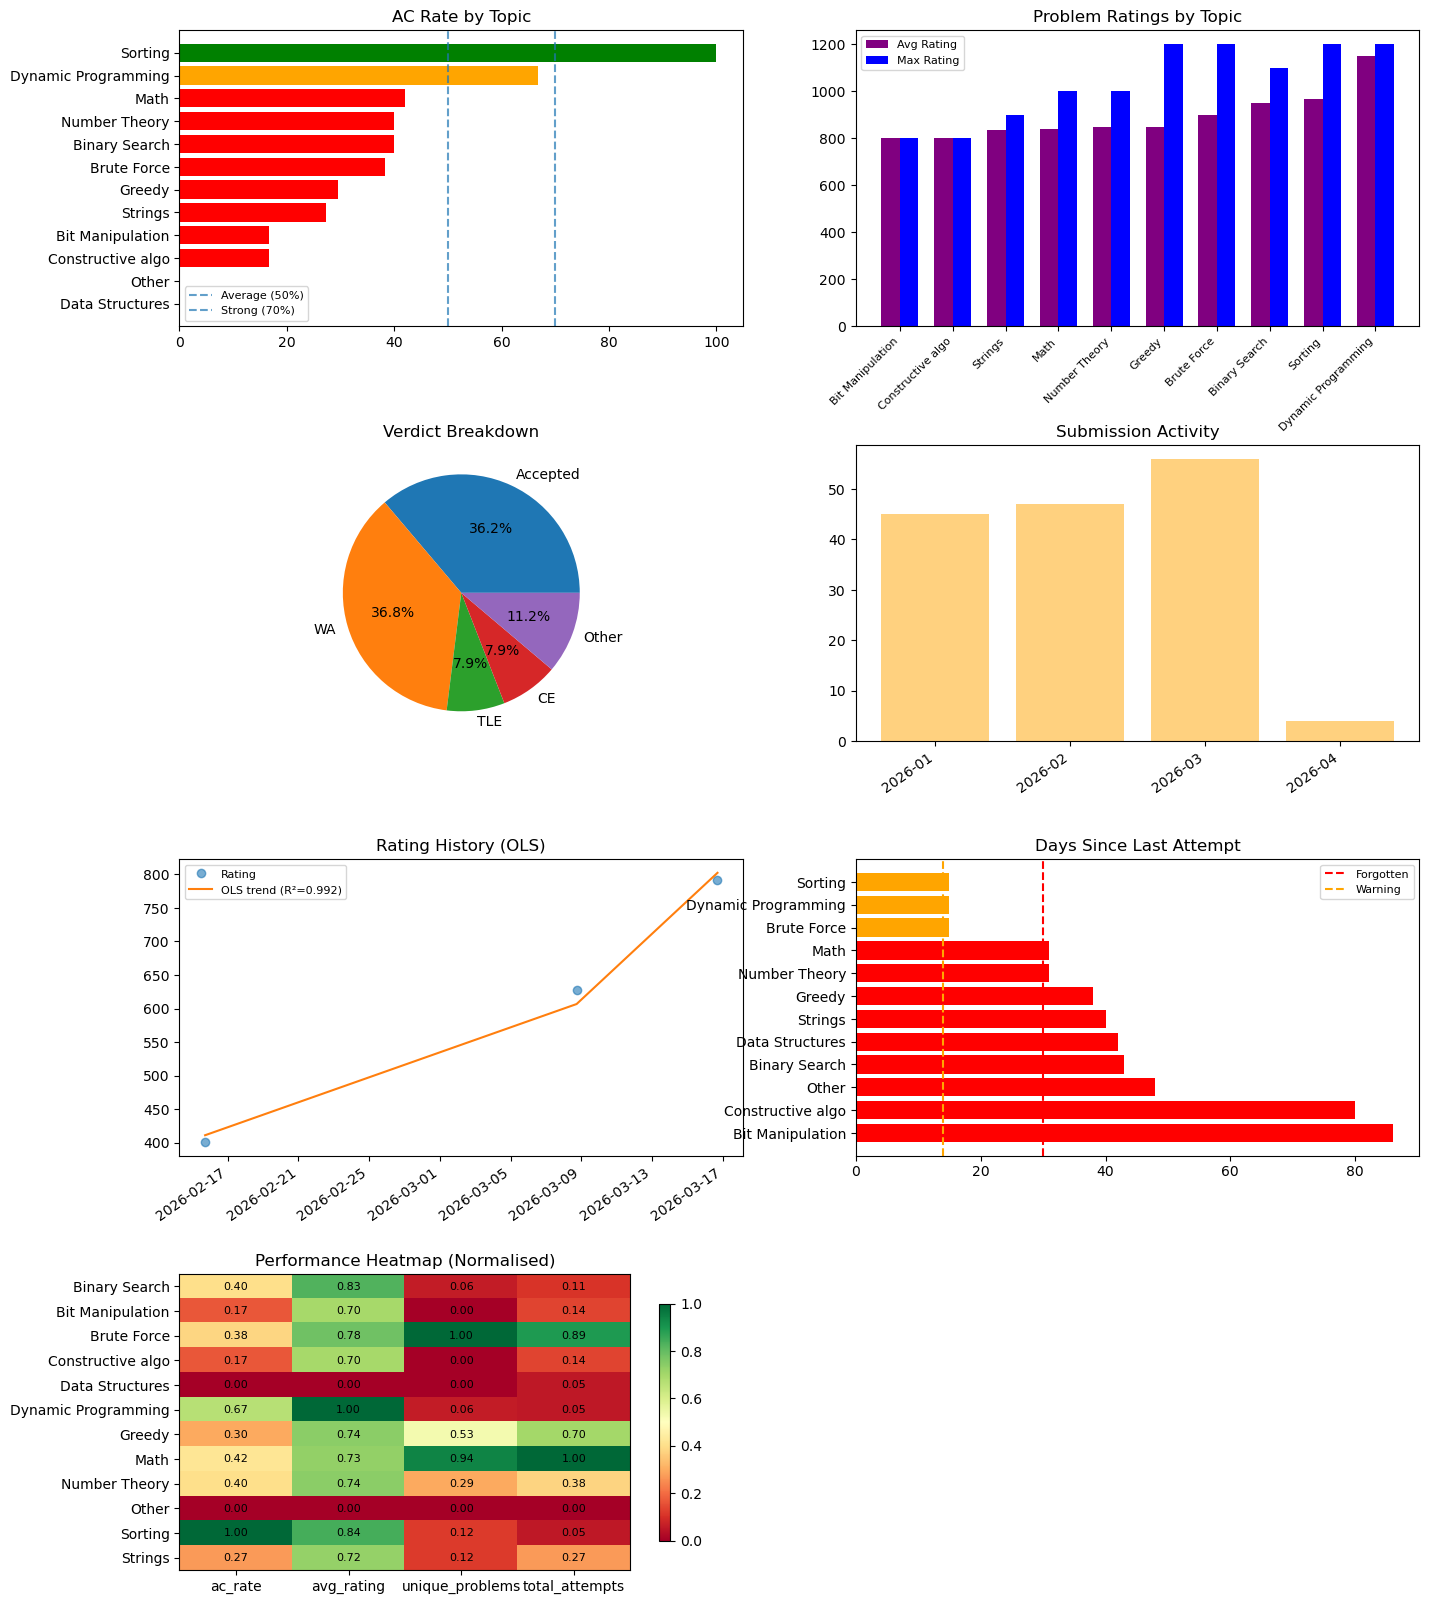

### Topic Statistics

,topic,total_attempts,accepted,ac_rate,avg_rating
0,Data Structures,3,0,0.0,0.0
1,Other,1,0,0.0,0.0
2,Constructive algo,6,1,16.7,800.0
3,Bit Manipulation,6,1,16.7,800.0
4,Strings,11,3,27.3,833.3
5,Greedy,27,8,29.6,850.0
6,Brute Force,34,13,38.2,900.0
7,Binary Search,5,2,40.0,950.0
8,Number Theory,15,6,40.0,850.0
9,Math,38,16,42.1,837.5


### AI Recommendations (Priority Ordered)

Topic,Current Avg,Target Rating,Calculation Method,Priority,Suggested Problems
Data Structures,800,800,start from 800,62.50,[900] Simply Sitting on Chairs [900] Index and Maximum Value [900] Minimize Inversions [900] Odd Queries [900] Also Try Minecraft
Other,800,800,start from 800,62.50,[900] Course Wishes [900] Simply Sitting on Chairs [900] Array [900] Specialty String [900] Heapify 1
Bit Manipulation,800,800,start from 800,44.78,[900] Almost Ternary Matrix [900] Mocha and Math [900] ABC String [1000] Beautiful Numbers [800] Deletion Sort
Constructive algo,800,800,start from 800,44.78,[900] Course Wishes [900] Simply Sitting on Chairs [900] Array [900] Specialty String [900] Heapify 1
Strings,833,1033,Topic Scipy Reg + boost,34.10,[1000] Flipping Binary String [1000] Optimal Shifts [1000] Shohag Loves Strings [1000] Numeric String Template [1000] Swap and Delete
Greedy,850,1157,Topic Scipy Reg + boost,31.09,[1200] A Simple GCD Problem (Easy Version) [1200] ABAB Construction [1200] Sorting Game [1200] The Curse of the Frog [1200] First or Second
Brute Force,900,1157,Topic Scipy Reg + boost,22.61,[1200] The 67th XOR Problem [1200] Production of Snowmen [1200] Honey Cake [1200] Even Larger [1200] Two Large Bags
Binary Search,950,1150,Topic Scipy Reg + boost,22.23,[1200] The 67th XOR Problem [1100] Monster Game [1100] Huge Pile [1200] Split [1200] Retaliation
Number Theory,850,1160,Topic Scipy Reg + boost,21.41,[1200] A Simple GCD Problem (Easy Version) [1200] Honey Cake [1200] Add 0 or K [1200] Retaliation [1200] Shohag Loves XOR (Easy Version)
Math,838,1120,Topic Scipy Reg + boost,19.09,[1100] The 67th OEIS Problem [1100] Mickey Mouse Constructive [1100] Cyclists [1100] OutOfMemoryError [1100] Huge Pile


---

Processing @Ayushi006...


## CP Analysis for **@Ayushi006**

**Rank:** Newbie | **Rating:** 645

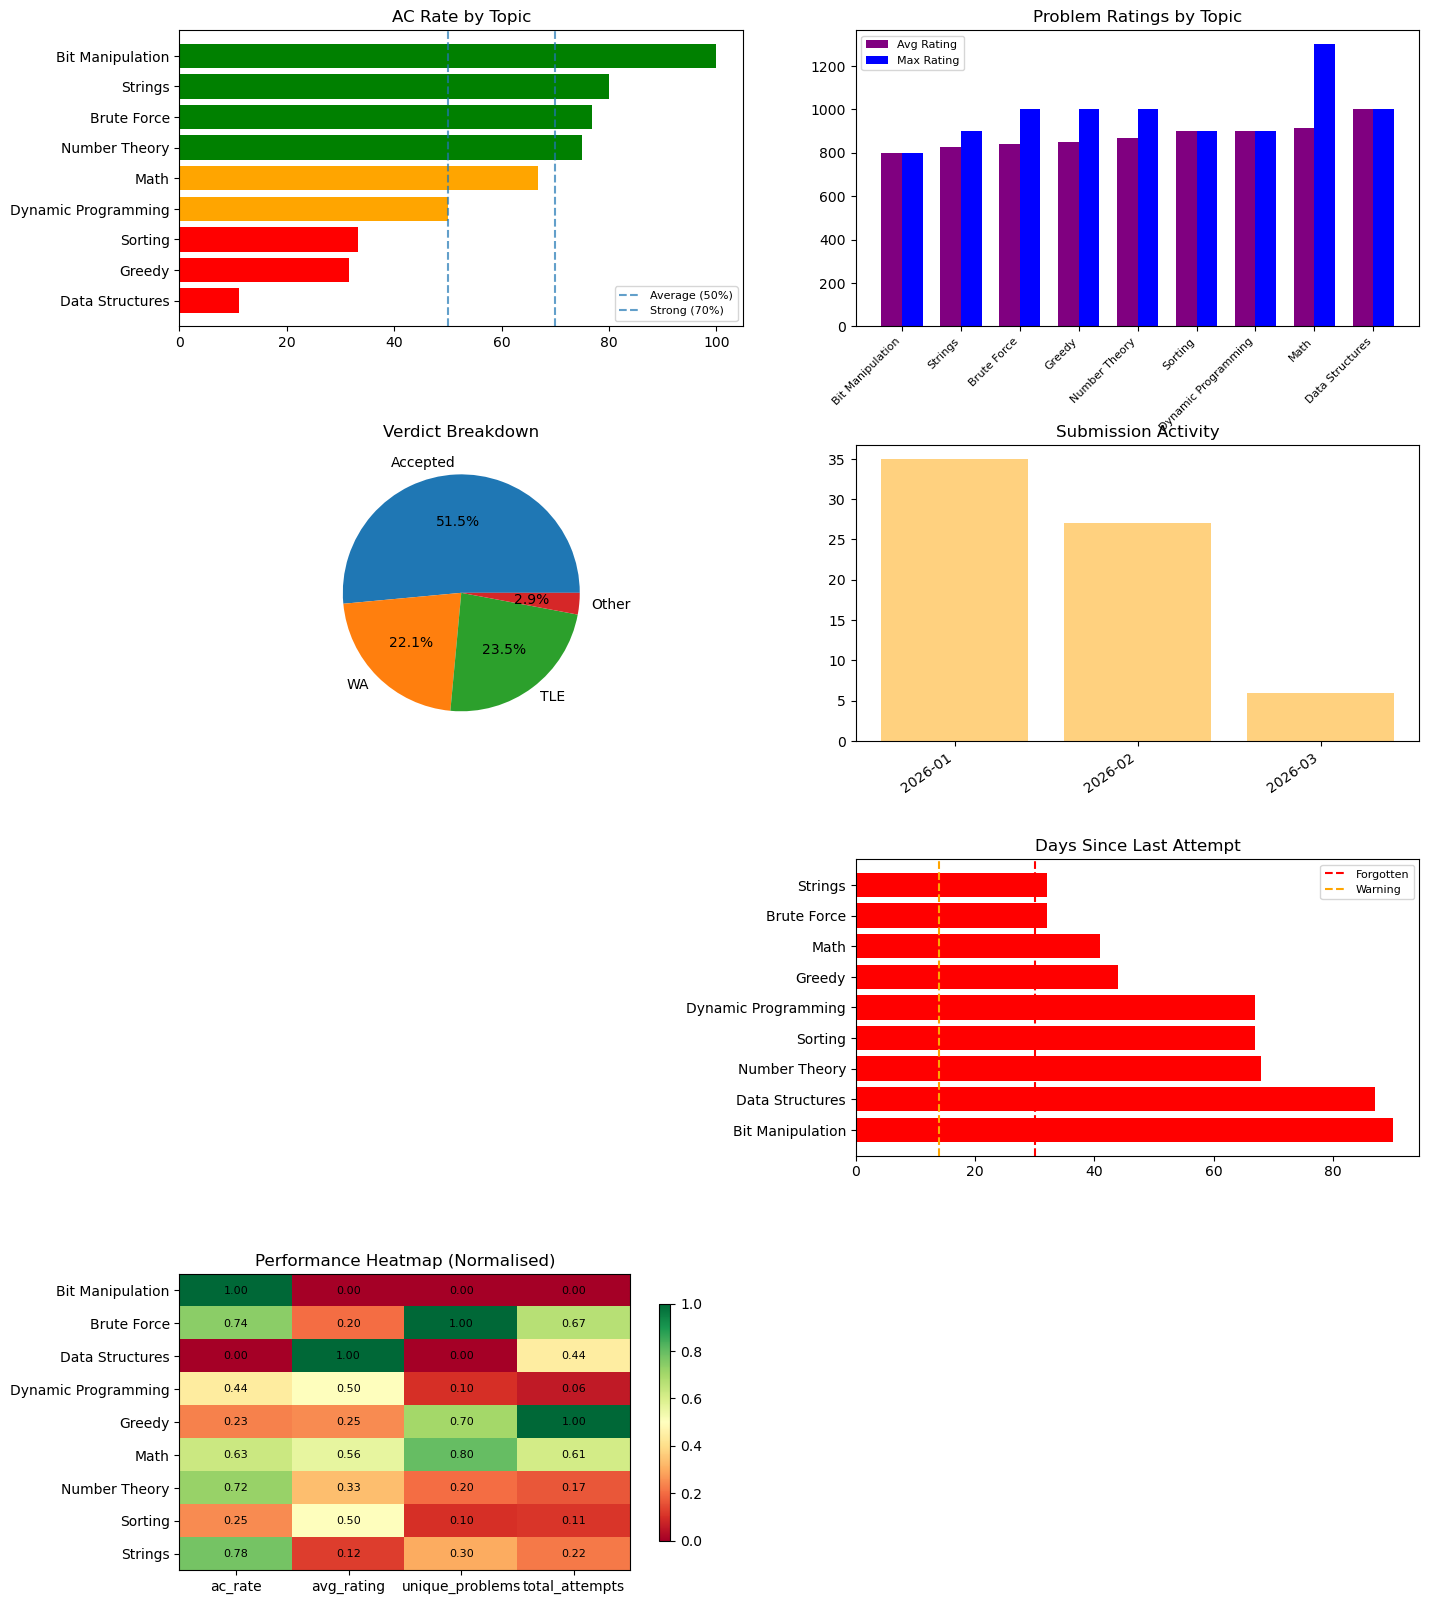

### Topic Statistics

,topic,total_attempts,accepted,ac_rate,avg_rating
0,Data Structures,9,1,11.1,1000.0
1,Greedy,19,6,31.6,850.0
2,Sorting,3,1,33.3,900.0
3,Dynamic Programming,2,1,50.0,900.0
4,Math,12,8,66.7,912.5
5,Number Theory,4,3,75.0,866.7
6,Brute Force,13,10,76.9,840.0
7,Strings,5,4,80.0,825.0
8,Bit Manipulation,1,1,100.0,800.0


### AI Recommendations (Priority Ordered)

Topic,Current Avg,Target Rating,Calculation Method,Priority,Suggested Problems
Data Structures,1000,800,start from 800,49.97,[900] Simply Sitting on Chairs [900] Index and Maximum Value [900] Minimize Inversions [900] Odd Queries [900] Also Try Minecraft
Greedy,850,1060,Topic Scipy Reg + boost,29.20,[1100] The 67th OEIS Problem [1100] Mickey Mouse Constructive [1100] Cyclists [1100] Dice Roll Sequence [1100] Yet Another MEX Problem
Sorting,900,800,start from 800,28.51,[900] Heapify 1 [900] Shifted MEX [900] The Picky Cat [900] Game of Mathletes [900] Penchick and Satay Sticks
Dynamic Programming,900,800,start from 800,14.14,[900] Impost or Sus [900] Chess For Three [900] Rudolf and the Ugly String [900] Laura and Operations [900] Ugu
Bit Manipulation,800,800,start from 800,11.40,[900] Almost Ternary Matrix [900] Mocha and Math [900] ABC String [1000] Beautiful Numbers [800] Deletion Sort
Number Theory,867,1067,Topic Scipy Reg + boost,9.44,[1100] The 67th OEIS Problem [1100] Blackslex and Number Theory [1100] Make it Equal [1100] Count Good Numbers [1100] MIN = GCD
Strings,825,1025,Topic Scipy Reg + boost,9.03,[1000] Flipping Binary String [1000] Optimal Shifts [1000] Shohag Loves Strings [1000] Numeric String Template [1000] Swap and Delete
Brute Force,840,1106,Topic Scipy Reg + boost,6.60,[1100] Cyclists [1100] Maximum Even Sum [1100] Shrinking Array [1100] Equal Values [1100] Fibonacci Cubes
Math,912,1289,Topic Scipy Reg + boost,5.96,[1300] Grid Covering [1300] Stamina and Tasks [1300] Absolute Cinema [1300] Secret message [1300] Product Queries


---

In [35]:
class UserSession:
    def __init__(self, handle):
        self.handle = handle
        self.user_info = None; self.raw_subs = []; self.rating_history = []
        self.df = None; self.stats_df = None; self.forgotten_df = None; self.trend = None
        self.recs = {}

class CPAnalyserEngine:
    def __init__(self):
        self.client= CFClient()

    def fetch_data(self, session: UserSession):
        session.user_info= self.client.fetch_user_info(session.handle)
        if not session.user_info: 
            return False
        session.raw_subs= self.client.fetch_submissions(session.handle, 500)
        session.rating_history= self.client.fetch_rating_history(session.handle)
        save_raw_data_to_csv(session.handle, session.user_info, session.raw_subs, session.rating_history)
        return True

    def process_data(self, session: UserSession):
        session.df= process_submissions(session.raw_subs)
        if session.df.empty: 
            return False
        session.stats_df= compute_topic_stats(session.df)
        session.forgotten_df= detect_forgotten_topics(session.stats_df)
        session.trend= rating_trend(session.rating_history)
        return True

    def generate_recommendations(self, session: UserSession):
        all_topics= session.stats_df["topic"].tolist()
        session.recs= recommend(all_topics, session.stats_df, session.df)
        
        # Save recommendations CSV
        if session.recs:
            rec_rows= [{"topic": t, "target": r["target_rating"], "prob": p["title"]} for t, r in session.recs.items() for p in r["top_problems"]]
            if rec_rows: pd.DataFrame(rec_rows).to_csv(f"files/cf_recs_{session.handle}.csv", index=False)

    def display_notebook_report(self, session: UserSession):
        display(Markdown(f"## CP Analysis for **@{session.handle}**"))
        display(Markdown(f"**Rank:** {session.user_info.get('rank', 'N/A').title()} | **Rating:** {session.user_info.get('rating', 0)}"))
        
        # Plot Charts Side-by-Side
        render_dashboard(session.stats_df, session.trend, session.df, session.forgotten_df)
        
        # Display Detailed Stats DataFrame
        display(Markdown("### Topic Statistics"))
        df= session.stats_df[["topic", "total_attempts", "accepted", "ac_rate", "avg_rating"]].sort_values("ac_rate")
        df.index= sorted(df.index)
        display(df)
        
        # Display AI Recommendations DataFrame
        if session.recs:
            display(Markdown("### AI Recommendations (Priority Ordered)"))
            rec_display = []
            for topic, data in session.recs.items():
            #gives clickable Markdown hyperlinks for each problem

                probs= [f"[{p['rating']}] <a href='{p['link']}' target='_blank'>{p['title']}</a>" for p in data['top_problems']]
                rec_display.append({
                    "Topic": topic,
                    "Current Avg": data["current_avg_rating"],
                    "Target Rating": data["target_rating"],
                    "Calculation Method": data["target_method"],
                    "Priority": data["priority_score"],
                    "Suggested Problems": " <br> ".join(probs)
                    })

        # Use HTML rendering so Markdown links are clickable in the DataFrame
            df_html= pd.DataFrame(rec_display).to_html(escape=False, index=False)
            display(HTML("""
            <style>
            table td { text-align: left !important; vertical-align: top; }
            table th { text-align: left !important; }
            </style>
            """ + df_html))
            
        display(Markdown("---"))

    def run(self, handle):
        print(f"Processing @{handle}...")
        session = UserSession(handle)
        if self.fetch_data(session) and self.process_data(session):
            self.generate_recommendations(session)
            self.display_notebook_report(session)



handles_input = input("Enter Codeforces handles (comma separated): ")
handles = [h.strip() for h in handles_input.split(",") if h.strip()]

engine= CPAnalyserEngine()
for user in handles:
    engine.run(user)